# Business Problem

An e-commerce company introduced a redesigned landing page with the objective of increasing user conversion rates. To evaluate whether the redesigned page performs better than the existing version, the company conducted an A/B testing experiment.

Users were randomly assigned into two groups:

* **Control Group** → shown the old landing page
* **Treatment Group** → shown the new landing page

The key business objective is to determine whether the new landing page generates a statistically significant improvement in conversion rate before making a full-scale deployment decision.


# Main Objective

The primary objective of this analysis is to determine whether the new landing page leads to a higher conversion rate compared to the old landing page.

This project focuses on:

* Validating experiment data quality
* Comparing conversion performance between groups
* Performing statistical hypothesis testing
* Measuring confidence intervals
* Providing business recommendations based on statistical evidence


# Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("deep")

# Import Dataset

In [ ]:
df=pd.read_csv(r"ab_data.csv")

# Understanding Dataset

In [ ]:
df.head(5)

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [ ]:
df.tail(5)

,user_id,timestamp,group,landing_page,converted
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0
294477,715931,2017-01-16 12:40:24.467417,treatment,new_page,0


In [ ]:
df.shape

(294478, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [ ]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [ ]:
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='object')

# Data Cleaning

Before performing statistical analysis, the dataset must be validated to ensure experiment integrity.

The following checks are performed:

- Missing value detection
- Duplicate record identification
- Validation of experiment group assignments
- Consistency between group and landing page mappings

This step is critical because incorrect experiment assignments can bias the A/B testing results.

In [ ]:
df.isnull().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Experiment Consistency Validation

In a valid A/B experiment:

- Users in the control group should only see the old page
- Users in the treatment group should only see the new page

Any mismatched assignments indicate experiment contamination and must be removed before analysis.

In [ ]:
# Check whether users were assigned correctly to landing pages
df.groupby(['group','landing_page']).size()

group      landing_page
control    new_page          1928
           old_page        145274
treatment  new_page        145311
           old_page          1965
dtype: int64

In [ ]:
# Filter dataset to retain only valid experiment assignments
df = df[
(df['group']=='control')&(df['landing_page']=='old_page') |
(df['group']=='treatment')&(df['landing_page']=='new_page')
]

In [ ]:
# Verify that mismatched records were removed successfully
df.groupby(['group','landing_page']).size()

group      landing_page
control    new_page          1928
           old_page        145274
treatment  new_page        145311
           old_page          1965
dtype: int64

# Feature Engineering

Additional time-based features were extracted from the timestamp column to analyze behavioral trends across:

- Hour of the day
- Day of the week
- Daily traffic patterns

These features help identify whether user activity and conversion behavior vary over time.

In [ ]:
# Convert timestamp column into datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract day, hour, and weekday from timestamp
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.day_name()

In [ ]:
# Display updated dataset columns after feature engineering
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted', 'day',
       'hour', 'weekday'],
      dtype='object')

# Exploratory Data Analysis (EDA)

In [ ]:
# Count users in each experiment group
df['group'].value_counts()

,count
group,
treatment,147276
control,147202


In [ ]:
# Calculate percentage distribution across experiment groups
(df['group'].value_counts(normalize=True) * 100).round(2)

,proportion
group,
treatment,50.01
control,49.99


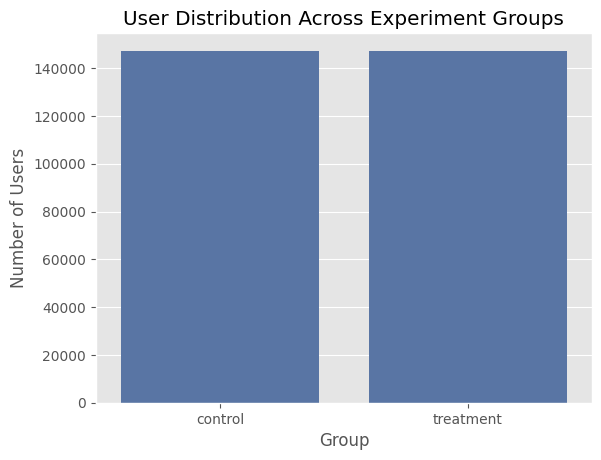

In [ ]:
sns.countplot(x='group', data=df)

plt.title('User Distribution Across Experiment Groups')
plt.xlabel('Group')
plt.ylabel('Number of Users')

plt.show()

### Detailed Insights
- The visualization shows that users were distributed almost equally between the control and treatment groups.
- Balanced allocation indicates proper randomization during the experiment setup.

In [ ]:
(df.groupby('group')['converted'].mean() * 100).round(2)

,converted
group,
control,12.04
treatment,11.89


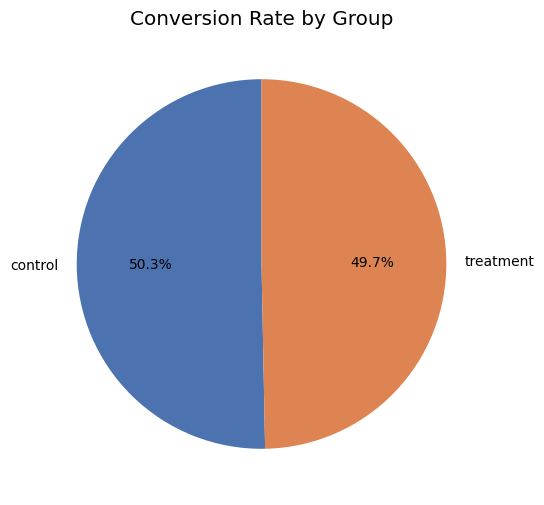

In [46]:
conversion_rate = df.groupby('group')['converted'].mean().reset_index()

plt.figure(figsize=(6,6))

plt.pie(
    conversion_rate['converted'],
    labels=conversion_rate['group'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Conversion Rate by Group')

plt.show()

### Detailed Insights
- The conversion rates of the treatment and control groups appear very close to each other.
- There is no visually strong uplift in conversion for the new landing page.

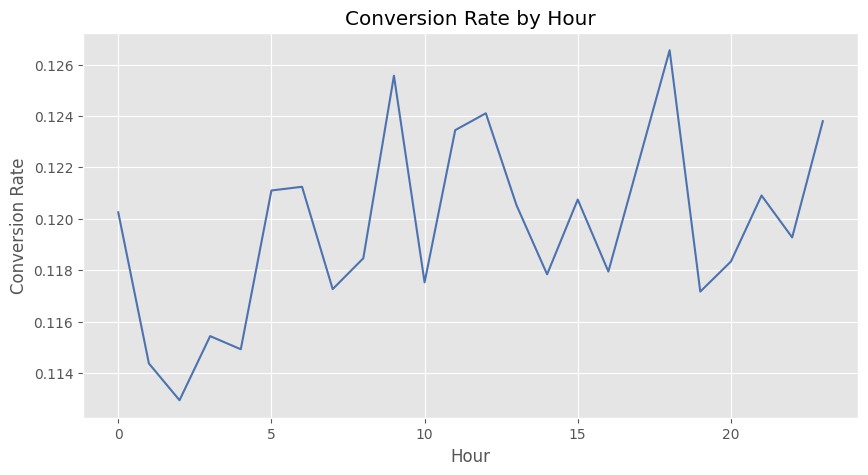

In [ ]:
hourly_conversion = df.groupby('hour')['converted'].mean()

hourly_conversion.plot(kind='line', figsize=(10,5))

plt.title('Conversion Rate by Hour')
plt.ylabel('Conversion Rate')
plt.xlabel('Hour')

plt.show()

### Detailed Insights
- Conversion rates fluctuate across different hours of the day.
- Certain time windows show relatively higher engagement and conversion activity.

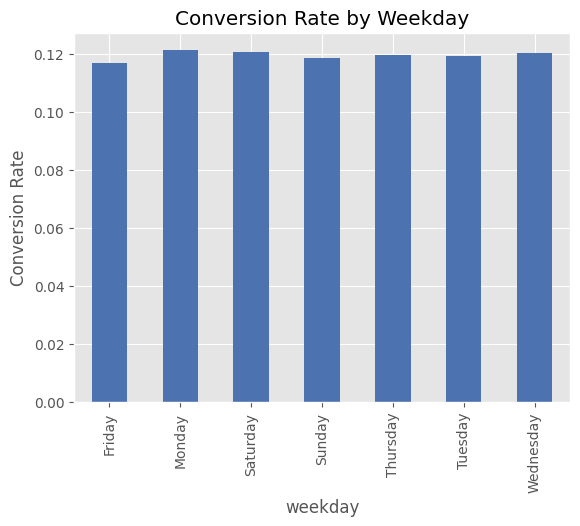

In [42]:
weekday_conversion = df.groupby('weekday')['converted'].mean()

weekday_conversion.plot(kind='bar')

plt.title('Conversion Rate by Weekday')
plt.ylabel('Conversion Rate')

plt.show()

### Detailed Insights
- Conversion performance varies slightly across weekdays.
- Some days consistently generate stronger conversion activity than others.

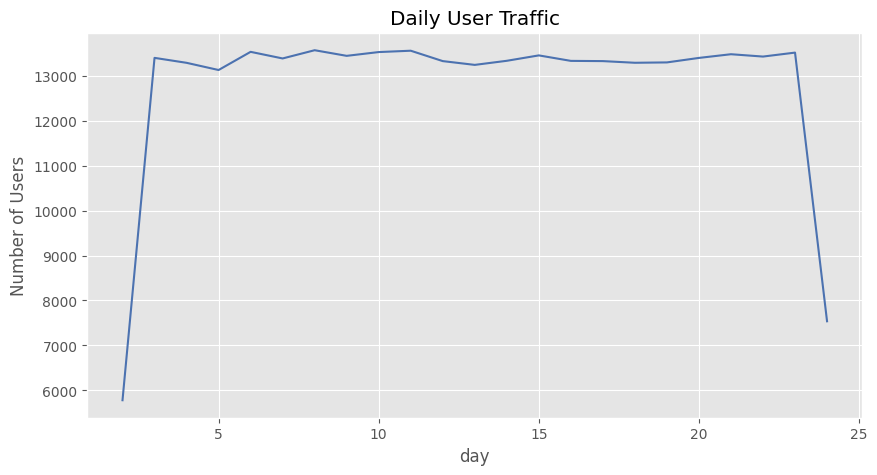

In [45]:
daily_traffic = df.groupby('day').size()

daily_traffic.plot(kind='line', figsize=(10,5))

plt.title('Daily User Traffic')
plt.ylabel('Number of Users')

plt.show()

### Detailed Insights
- Daily user traffic remains relatively stable throughout the experiment period.
- No major spikes or sudden drops are observed.

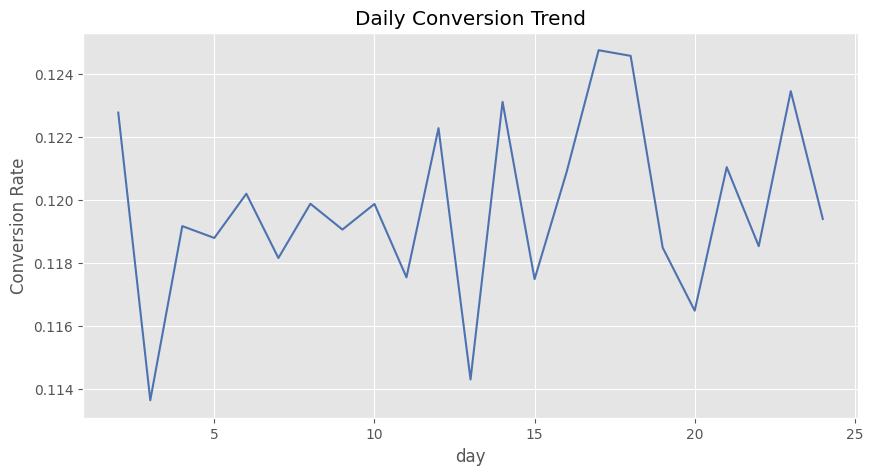

In [44]:
daily_conversion = df.groupby('day')['converted'].mean()

daily_conversion.plot(kind='line', figsize=(10,5))

plt.title('Daily Conversion Trend')
plt.ylabel('Conversion Rate')

plt.show()

### Detailed Insights
- Daily conversion rates fluctuate moderately across the experiment timeline.
- No strong upward or downward trend is observed.

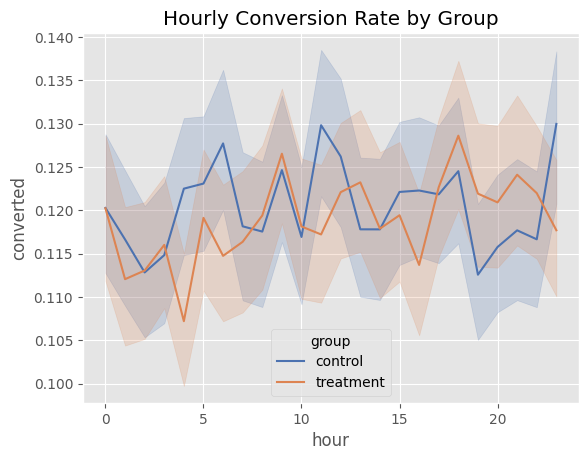

In [43]:
sns.lineplot(data=df, x='hour', y='converted', hue='group')

plt.title('Hourly Conversion Rate by Group')

plt.show()

### Detailed Insights
- Both control and treatment groups follow very similar hourly conversion patterns.
- No consistent time period shows strong dominance by the treatment group.

# Hypothesis Testing

The objective of the hypothesis test is to determine whether the new landing page produces a higher conversion rate than the existing landing page.

## Null Hypothesis (H₀)

The new landing page does not improve the conversion rate.

## Alternative Hypothesis (H₁)

The new landing page improves the conversion rate.

A one-tailed two-proportion Z-test is used because the objective is specifically to test whether the new page performs better than the old page.


# Statistical Assumptions

The two-proportion Z-test assumes:

- Independent observations
- Random assignment of users
- Sufficiently large sample sizes
- Binary conversion outcomes

Given the large experiment size, the assumptions required for the Z-test are reasonably satisfied.

In [ ]:
# Extracts required metrics for the two-proportion Z-test.
control_group = df[df['group'] == 'control']
treatment_group = df[df['group'] == 'treatment']

control_converted = control_group['converted'].sum()
treatment_converted = treatment_group['converted'].sum()

control_size = control_group.shape[0]
treatment_size = treatment_group.shape[0]

In [ ]:
# Tests whether the new landing page performs significantly better than the old page.
from statsmodels.stats.proportion import proportions_ztest

conversions = [treatment_converted, control_converted]
sample_sizes = [treatment_size, control_size]

z_stat, p_value = proportions_ztest(conversions, sample_sizes, alternative='larger')

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -1.2369217547321678
P-value: 0.8919419336512124


### Interpretation

- A low p-value (< 0.05) would indicate statistical evidence that the new landing page performs better.
- A high p-value suggests insufficient evidence to conclude that the new page improves conversion rates.

The observed p-value indicates that the conversion difference is not statistically significant.

# Confidence Interval

In [ ]:
# Calculate confidence interval for difference in conversion rates
from statsmodels.stats.proportion import confint_proportions_2indep

low_ci, high_ci = confint_proportions_2indep(
    count1=treatment_converted,
    nobs1=treatment_size,
    count2=control_converted,
    nobs2=control_size,
    method='wald'
)

print("Confidence Interval:")
print(low_ci, high_ci)

Confidence Interval:
-0.003824096247825661 0.0008648966596705573


### Confidence Interval Interpretation

The confidence interval estimates the likely range of the true difference in conversion rates between the treatment and control groups.
Since the interval includes zero, the observed difference may be due to random variation rather than a genuine improvement from the new landing page.

# Final Conclusion

The A/B testing analysis indicates that the redesigned landing page did not produce a statistically significant improvement in conversion rate compared to the existing landing page.

Key findings from the experiment include:

* Conversion rates between both groups were very similar
* The p-value from the two-proportion Z-test exceeded the significance threshold of 0.05
* The confidence interval included zero, suggesting that the observed difference may be attributable to random chance

Based on the statistical evidence, there is insufficient support to conclude that the new landing page outperforms the current version.


# Business Recommendation

Based on the experimental results, deploying the new landing page is not currently recommended because the observed improvement in conversion rate is not statistically significant.

Recommended next steps:

* Retain the existing landing page
* Conduct additional user behavior analysis
* Investigate alternative landing page designs
* Perform segmented analysis across device type, traffic source, or user demographics
* Run future experiments with stronger design variations

The current redesign may not provide enough user experience improvement to meaningfully influence conversion behavior.


# Limitations

This analysis has several limitations:

- Only overall conversion rate was analyzed
- User-level behavioral factors were not considered
- External influences such as traffic quality and marketing campaigns were not evaluated
- Long-term customer retention impact was not measured

Future experiments could incorporate deeper segmentation and behavioral analytics.